# E10 Muon Variant And Normalization Ablation

### Problem

This notebook asks which part of Muon explains its behavior: polar matrix geometry, approximation quality, or simple gradient normalization. It reuses representative Matrix Sensing and Matrix Factorization settings from the geometry diagnostics.

For Matrix Sensing settings,

$$y_i=\langle A_i,X^\star\rangle+\xi_i,\qquad f(X)=\frac{1}{2m}\sum_{i=1}^{m}(\langle A_i,X\rangle-y_i)^2,$$

with Gaussian measurements, $m=\alpha dr$, and direct Gaussian initialization $X_0=10^{-2}G_0$. For Matrix Factorization settings,

$$\widehat X=LR^\top,\qquad g(L,R)=\frac{1}{2d^2}\lVert LR^\top-X^\star\rVert_F^2,$$

with Gaussian target construction $X^\star=U\operatorname{diag}(s)V^\top$ and factor initialization $L_0=aG_L$, $R_0=bG_R$.

The optimizer variants compare several update geometries. Exact Muon replaces a matrix gradient $G=P\Sigma Q^\top$ by its polar direction $PQ^\top$. Newton-Schulz variants approximate this polar direction using different iteration counts. Truncated and randomized variants approximate the same spectral direction with lower-rank or randomized computations. Normalized SGD baselines divide the gradient by Frobenius, spectral, or layerwise norms without using the full polar geometry.

The experiment fixes representative problem regimes and varies optimizer variant. Its purpose is to decide whether observed Muon behavior is best explained by the polar direction itself, approximation fidelity, or merely normalized step size.

When reading the results, focus first on accuracy-cost scatter plots, then compare Muon-variant recovery bars against normalized-SGD baselines. Use cosine and update-rank diagnostics to tell whether an accuracy difference comes from geometry or scale normalization. This notebook is expensive because it combines $8$ settings, $12$ algorithms, $30$ seeds, and up to $600$ steps, for a maximum of $1728000$ optimization steps before early stopping. It also records repeated spectral diagnostics; exact, truncated, randomized, and spectral-normalized variants perform SVD-like computations.

## Implementation Details: Skip Unless Modifying The Experiment

The code below is visible for reproducibility. A reader can skip it unless changing the grid, optimizer definitions, stopping rule, diagnostics, or plotting calls.

In [1]:
import math
import os
import pathlib
import sys
import time
for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import plotting
import problems.MatrixConstruction
import problems.MatrixFactorization
import problems.MatrixSensing
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Desktop/muonexperiment
torch   = 2.11.0


/opt/anaconda3/envs/muonexperiment-torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Parameters And Runs


In [2]:
NOTEBOOK_ID = "E10 Muon variants"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = [
    "Muon", "Muon-Exact", "Muon-NS-1", "Muon-NS-10", "Muon-Truncated", "Muon-RandSVD",
    "Shampoo", "Adam", "SGD", "NormalizedSGD", "SpectralNormSGD", "LayerwiseNormalizedSGD",
]
SEEDS = list(range(30))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 600

BASE_SPEC = dict(
    d=60,
    rank=5,
    lr=0.01,
    iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
    diagnostic_every=1 if SMOKE_TEST else 20,
    early_stop=True,
    early_stop_min_steps=100,
    early_stop_patience=20,
    early_stop_min_delta=1e-4,
    device_type=DEVICE.type,
    dtype_name=DTYPE_NAME,
)
SETTINGS = [
    dict(setting="MS-easy", problem="MatrixSensing", spectrum="hard-cutoff", kappa=1.0, m_multiplier=8, noise=0.0, init_scale=0.01),
    dict(setting="MS-hard", problem="MatrixSensing", spectrum="exponential-decay", kappa=100.0, m_multiplier=6, noise=0.0, init_scale=0.01),
    dict(setting="MS-undersampled", problem="MatrixSensing", spectrum="exponential-decay", kappa=100.0, m_multiplier=1, noise=0.0, init_scale=0.01),
    dict(setting="MS-noisy", problem="MatrixSensing", spectrum="exponential-decay", kappa=100.0, m_multiplier=4, noise=0.03, init_scale=0.01),
    dict(setting="MF-standard", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=0.01, right_scale=0.01),
    dict(setting="MF-tiny", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-4, right_scale=1e-4),
    dict(setting="MF-overparam", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=20, left_scale=0.01, right_scale=0.01),
    dict(setting="MF-imbalanced", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-4, right_scale=1.0),
]
NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([
    {**BASE_SPEC, **setting, "algo": algo, "seed": seed}
    for setting in SETTINGS
    for algo in ALGOS
    for seed in SEEDS
])
runs.insert(0, "run_id", range(len(runs)))

print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"smoke_test={SMOKE_TEST}, steps_per_run={BASE_SPEC['iters']}, diagnostic_every={BASE_SPEC['diagnostic_every']}")
print(f"runs={len(runs)}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
IPython.display.display(runs)


device=cpu, workers=8, backend=loky
smoke_test=False, steps_per_run=600, diagnostic_every=20
runs=288, max_total_steps=172800


,run_id,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,spectrum,kappa,m_multiplier,noise,init_scale,algo,seed,factor_rank,left_scale,right_scale
0,0,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,8.0,0.0,0.01,Muon,0,NaN,NaN,NaN
1,1,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,8.0,0.0,0.01,Muon,1,NaN,NaN,NaN
2,2,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,8.0,0.0,0.01,Muon,2,NaN,NaN,NaN
3,3,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,8.0,0.0,0.01,Muon-Exact,0,NaN,NaN,NaN
4,4,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,8.0,0.0,0.01,Muon-Exact,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,283,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,NaN,NaN,NaN,SpectralNormSGD,1,5.0,0.0001,1.0
284,284,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,NaN,NaN,NaN,SpectralNormSGD,2,5.0,0.0001,1.0
285,285,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,NaN,NaN,NaN,LayerwiseNormalizedSGD,0,5.0,0.0001,1.0
286,286,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,NaN,NaN,NaN,LayerwiseNormalizedSGD,1,5.0,0.0001,1.0


### Pseudocode

```text
for each representative setting, Muon variant or normalization baseline, seed:
    initialize the Matrix Sensing or Matrix Factorization problem
    define step(state): loss -> backward -> clone gradient -> optimizer.step -> actual update
    record recovery, cost, descent alignment, and update rank every diagnostic interval
compare accuracy-cost, Muon approximation quality, and normalization baselines
```


### Worker Definition


In [3]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_optimizer(algo, params, lr, rank):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        try:
            return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
        except TypeError:
            pass
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=5)
    if algo in {"Muon-Exact", "MuonExact"}:
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="exact")
    if algo == "Muon-NS-1":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=1)
    if algo == "Muon-NS-10":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=10)
    if algo == "Muon-Truncated":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="truncated", rank=rank)
    if algo == "Muon-RandSVD":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="randsvd", rank=rank, oversample=5, power_iters=1)
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr, beta2=0.9, epsilon=1e-8)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if algo == "NormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="fro")
    if algo == "SpectralNormSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="spectral")
    if algo == "LayerwiseNormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="fro")
    raise ValueError(f"unknown algo: {algo}")


def show_figure(fig):
    IPython.display.display(fig)
    plt.close(fig)


def single_run(run):
    run = dict(run)
    d = int(run["d"])
    rank = int(run["rank"])
    seed = int(run["seed"])
    iters = int(run["iters"])
    diagnostic_every = int(run["diagnostic_every"])
    early_stop = bool(run["early_stop"])
    early_stop_min_steps = int(run["early_stop_min_steps"])
    early_stop_patience = int(run["early_stop_patience"])
    early_stop_min_delta = float(run["early_stop_min_delta"])
    device = torch.device(run["device_type"])
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)

    if run["problem"] == "MatrixSensing":
        problem = problems.MatrixSensing.make_matrix_sensing_problem(
            d,
            rank,
            noise=float(run["noise"]),
            dist="normal",
            spectrum=run["spectrum"],
            kappa=float(run["kappa"]),
            seed=seed,
            device=device,
            dtype=dtype,
            m_multiplier=float(run["m_multiplier"]),
        )
        x = torch.nn.Parameter(problems.MatrixConstruction.randn((d, d), seed + 3000, device, dtype) * float(run["init_scale"]))
        params = [x]
        estimate = lambda: x.detach()
        objective = lambda: problem.loss(x)
        factor_metrics = lambda: {}
    else:
        factor_rank = int(run["factor_rank"])
        problem = problems.MatrixFactorization.make_matrix_factorization_problem(
            d,
            rank,
            spectrum=run["spectrum"],
            kappa=float(run["kappa"]),
            seed=seed,
            device=device,
            dtype=dtype,
            factor_rank=factor_rank,
        )
        left = torch.nn.Parameter(problems.MatrixConstruction.randn((d, factor_rank), seed + 3000, device, dtype) * float(run["left_scale"]))
        right = torch.nn.Parameter(problems.MatrixConstruction.randn((d, factor_rank), seed + 4000, device, dtype) * float(run["right_scale"]))
        params = [left, right]
        estimate = lambda: left.detach() @ right.detach().T
        objective = lambda: problem.loss(left, right)
        factor_metrics = lambda: {
            "left_norm": float(left.detach().norm().cpu()),
            "right_norm": float(right.detach().norm().cpu()),
            "balancedness": util.diagnostics.balancedness(left, right),
        }

    optimizer = make_optimizer(run["algo"], params, float(run["lr"]), rank)
    initial_loss = float(objective().detach().cpu())
    best_loss = None
    early_stop_wait = 0
    rows = []
    start_time = time.perf_counter()

    for step_index in range(1, iters + 1):
        optimizer.zero_grad(set_to_none=True)
        loss = objective()
        loss.backward()
        gradients = [param.grad.detach().clone() for param in params]
        before = [param.detach().clone() for param in params]
        optimizer.step()
        updates = [param.detach() - old for param, old in zip(params, before)]
        loss_value = float(loss.detach().cpu())

        if best_loss is None:
            best_loss = loss_value
        elif best_loss - loss_value >= early_stop_min_delta:
            best_loss = loss_value
            early_stop_wait = 0
        else:
            early_stop_wait += 1

        stop_reason = ""
        if not math.isfinite(loss_value) or loss_value > max(1e6, 1e6 * max(initial_loss, 1e-12)):
            stop_reason = "diverged"
        elif early_stop and step_index >= early_stop_min_steps and early_stop_wait >= early_stop_patience:
            stop_reason = "early_stop_patience"
        elif step_index == iters:
            stop_reason = "max_iters"

        should_record = step_index == 1 or step_index % diagnostic_every == 0 or bool(stop_reason)
        if should_record:
            x_hat = estimate()
            grad_stats = util.diagnostics.aggregate_matrix_diagnostics(gradients, prefix="grad")
            update_stats = util.diagnostics.aggregate_matrix_diagnostics(updates, prefix="update")
            row = {
                **run,
                "initial_loss": initial_loss,
                "step": step_index,
                "loss": loss_value,
                "best_loss": best_loss,
                "early_stop_wait": early_stop_wait,
                "elapsed_s": time.perf_counter() - start_time,
                "stop_reason": stop_reason,
                "relative_matrix_error": util.diagnostics.relative_matrix_error(x_hat, problem.target),
                "solution_effective_rank": util.diagnostics.effective_rank(x_hat),
                "top_sv_relative_error": util.diagnostics.top_singular_value_error(x_hat, problem.target, k=rank),
                "grad_update_cosine": util.diagnostics.descent_alignment(gradients, updates),
                "relative_step_size": util.diagnostics.relative_step_size(before, updates),
                "update_to_grad_norm_ratio": update_stats["update_fro_norm"] / max(grad_stats["grad_fro_norm"], 1e-12),
                **grad_stats,
                **update_stats,
                **factor_metrics(),
            }
            target_sv = torch.linalg.svdvals(problem.target.detach())[:rank]
            solution_sv = torch.linalg.svdvals(x_hat.detach())[:rank]
            for idx in range(rank):
                row[f"target_sv_{idx + 1}"] = float(target_sv[idx].cpu()) if idx < len(target_sv) else 0.0
                row[f"solution_sv_{idx + 1}"] = float(solution_sv[idx].cpu()) if idx < len(solution_sv) else 0.0
            rows.append(row)
        if stop_reason:
            break

    return pd.DataFrame(rows)


## Results

The execute cell materializes the long per-step `runs` table. The saved outputs below are the experimental results to inspect.

In [4]:
runs = util.run_experiments(
    runs,
    single_run,
    num_workers=NUM_WORKERS,
    backend=JOBLIB_BACKEND,
    algo_order=ALGOS,
    sort_columns=("run_id", "step"),
    desc=NOTEBOOK_ID,
)
IPython.display.display(runs)


E10 Muon variants:   0%|          | 0/288 [00:00<?, ?run/s]

E10 Muon variants:   0%|          | 1/288 [00:04<19:50,  4.15s/run]

E10 Muon variants:   1%|          | 2/288 [00:04<08:29,  1.78s/run]

E10 Muon variants:   1%|▏         | 4/288 [00:04<03:19,  1.43run/s]

E10 Muon variants:   2%|▏         | 6/288 [00:04<02:02,  2.30run/s]

...

E10 Muon variants:  76%|███████▌  | 219/288 [00:24<00:00, 98.56run/s]

E10 Muon variants:  84%|████████▎ | 241/288 [00:24<00:00, 114.16run/s]

E10 Muon variants:  91%|█████████▏| 263/288 [00:24<00:00, 138.19run/s]

E10 Muon variants: 100%|██████████| 288/288 [00:24<00:00, 11.73run/s] 

,run_id,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,solution_sv_2,target_sv_3,solution_sv_3,target_sv_4,solution_sv_4,target_sv_5,solution_sv_5,left_norm,right_norm,balancedness
0,0,60,5,0.01,600,20,True,100,20,0.0001,...,0.138572,1.0,0.136101,1.0,0.127884,1.0,0.125979,NaN,NaN,NaN
1,0,60,5,0.01,600,20,True,100,20,0.0001,...,0.263448,1.0,0.260810,1.0,0.252213,1.0,0.242799,NaN,NaN,NaN
2,0,60,5,0.01,600,20,True,100,20,0.0001,...,0.440691,1.0,0.438002,1.0,0.422635,1.0,0.412300,NaN,NaN,NaN
3,0,60,5,0.01,600,20,True,100,20,0.0001,...,0.572551,1.0,0.550864,1.0,0.541050,1.0,0.531852,NaN,NaN,NaN
4,0,60,5,0.01,600,20,True,100,20,0.0001,...,0.607143,1.0,0.599684,1.0,0.574055,1.0,0.547868,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1893,287,60,5,0.01,600,20,True,100,20,0.0001,...,0.494800,1.0,0.419465,1.0,0.309386,1.0,0.236668,0.149742,17.585793,0.999853
1894,287,60,5,0.01,600,20,True,100,20,0.0001,...,0.590735,1.0,0.496774,1.0,0.361393,1.0,0.262928,0.174931,17.679978,0.999804
1895,287,60,5,0.01,600,20,True,100,20,0.0001,...,0.704155,1.0,0.599877,1.0,0.425007,1.0,0.310208,0.197213,17.783112,0.999759
1896,287,60,5,0.01,600,20,True,100,20,0.0001,...,0.816837,1.0,0.721534,1.0,0.544650,1.0,0.396471,0.221996,17.886387,0.999705


### Result Tables


In [5]:
ordered_runs = runs.sort_values(["run_id", "step"])
dynamic_columns = [
    "step", "initial_loss", "loss", "best_loss", "early_stop_wait", "elapsed_s", "stop_reason",
    "relative_matrix_error", "solution_effective_rank", "top_sv_relative_error", "grad_update_cosine",
    "relative_step_size", "update_to_grad_norm_ratio", "grad_fro_norm", "grad_op_norm",
    "grad_effective_rank", "grad_stable_rank", "update_fro_norm", "update_op_norm",
    "update_effective_rank", "update_stable_rank", "left_norm", "right_norm", "balancedness",
]
dynamic_columns += [f"target_sv_{idx}" for idx in range(1, 8)] + [f"solution_sv_{idx}" for idx in range(1, 8)]
run_summary = ordered_runs.groupby("run_id", as_index=False).first().drop(columns=dynamic_columns, errors="ignore")
run_summary = run_summary.merge(
    ordered_runs.groupby("run_id", as_index=False).agg(
        initial_loss=("initial_loss", "first"),
        final_loss=("loss", "last"),
        min_loss=("loss", "min"),
        relative_matrix_error=("relative_matrix_error", "last"),
        top_sv_relative_error=("top_sv_relative_error", "last"),
        solution_effective_rank=("solution_effective_rank", "last"),
        grad_update_cosine=("grad_update_cosine", "last"),
        update_effective_rank=("update_effective_rank", "last"),
        relative_step_size=("relative_step_size", "last"),
        actual_steps=("step", "last"),
        time_s=("elapsed_s", "last"),
        stop_reason=("stop_reason", "last"),
    ),
    on="run_id",
)
run_summary["time_per_step"] = run_summary["time_s"] / run_summary["actual_steps"].clip(lower=1)
run_summary["stopped_early"] = run_summary["stop_reason"].eq("early_stop_patience")
run_summary["diverged"] = run_summary["stop_reason"].eq("diverged")
run_summary["algo"] = pd.Categorical(run_summary["algo"], categories=ALGOS, ordered=True)
run_summary = run_summary.sort_values(["algo", "setting", "seed"]).reset_index(drop=True)
run_summary["algo"] = run_summary["algo"].astype(str)
IPython.display.display(run_summary)


,run_id,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,solution_effective_rank,grad_update_cosine,update_effective_rank,relative_step_size,actual_steps,time_s,stop_reason,time_per_step,stopped_early,diverged
0,252,60,5,0.01,600,20,True,100,20,0.0001,...,4.688325,0.250955,4.918192,0.005665,115,0.045161,early_stop_patience,0.000393,True,False
1,253,60,5,0.01,600,20,True,100,20,0.0001,...,4.721590,0.185309,4.946821,0.007100,100,0.040957,early_stop_patience,0.000410,True,False
2,254,60,5,0.01,600,20,True,100,20,0.0001,...,4.736903,0.268777,4.895366,0.006345,100,0.041177,early_stop_patience,0.000412,True,False
3,216,60,5,0.01,600,20,True,100,20,0.0001,...,5.127632,0.118353,17.369742,0.025025,100,0.047869,early_stop_patience,0.000479,True,False
4,217,60,5,0.01,600,20,True,100,20,0.0001,...,5.145532,0.247470,17.121100,0.025411,100,0.058312,early_stop_patience,0.000583,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,142,60,5,0.01,600,20,True,100,20,0.0001,...,46.060140,0.968463,48.905329,0.005909,100,0.433692,early_stop_patience,0.004337,True,False
284,143,60,5,0.01,600,20,True,100,20,0.0001,...,46.060269,0.966121,47.894902,0.005966,100,0.362626,early_stop_patience,0.003626,True,False
285,105,60,5,0.01,600,20,True,100,20,0.0001,...,47.552756,0.959934,47.764069,0.014542,104,0.112060,early_stop_patience,0.001077,True,False
286,106,60,5,0.01,600,20,True,100,20,0.0001,...,47.713481,0.634580,48.018101,0.007430,100,0.114108,early_stop_patience,0.001141,True,False


### Accuracy-Cost Scatter

The Problem cell asks whether Muon behavior comes from polar geometry, approximation quality, or normalization; this plot first separates accuracy from per-step cost for all variants.

Each scatter plot fixes one benchmark setting. A point is one optimizer or optimizer variant. The horizontal coordinate is seed-median time per step, the vertical coordinate is seed-median recovery error $e(\widehat X)$ on a log scale, and color is the method identity. The lower-left region is best: lower error and lower per-step cost. This plot separates algorithmic accuracy from implementation cost.

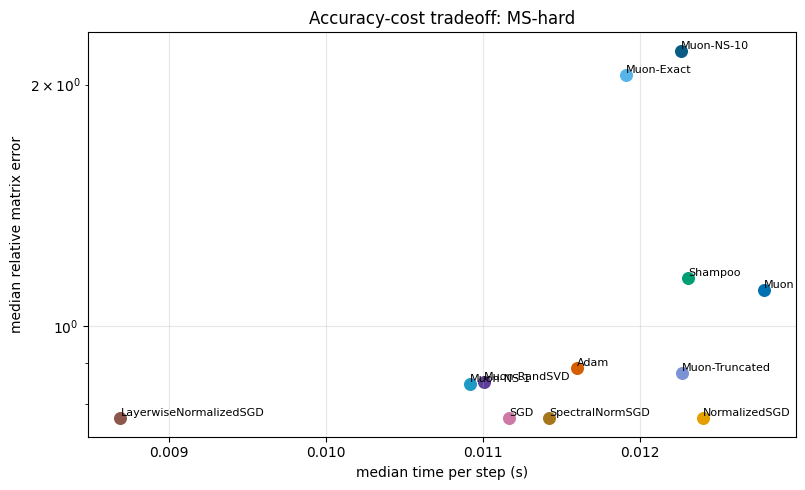

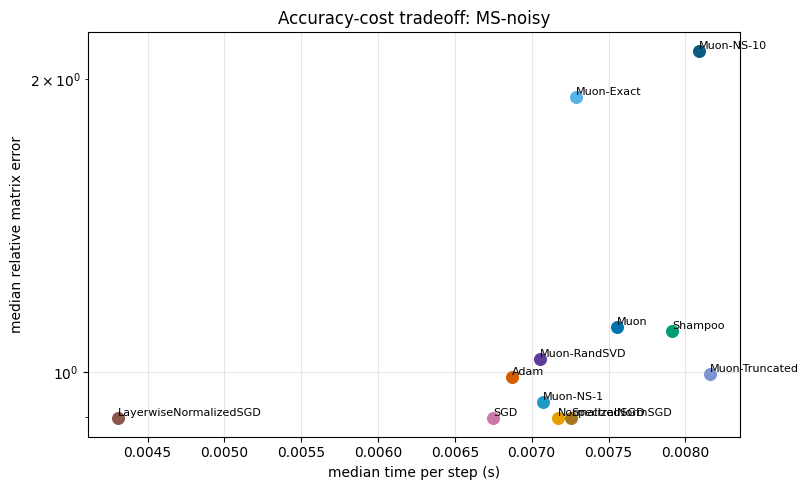

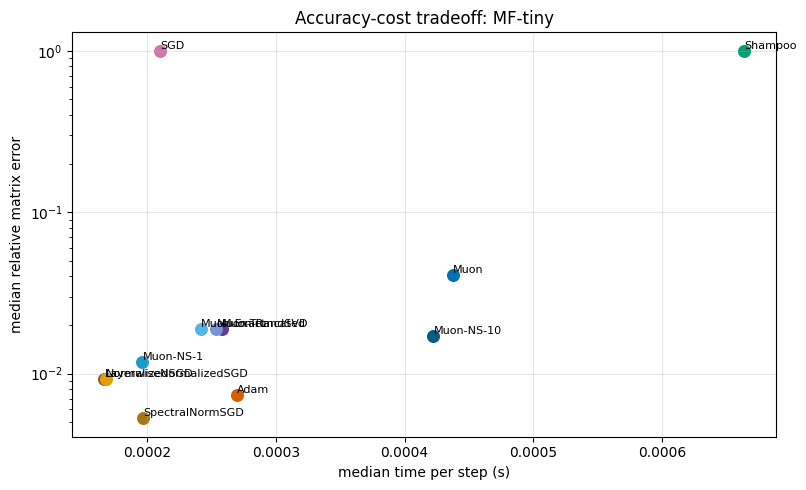

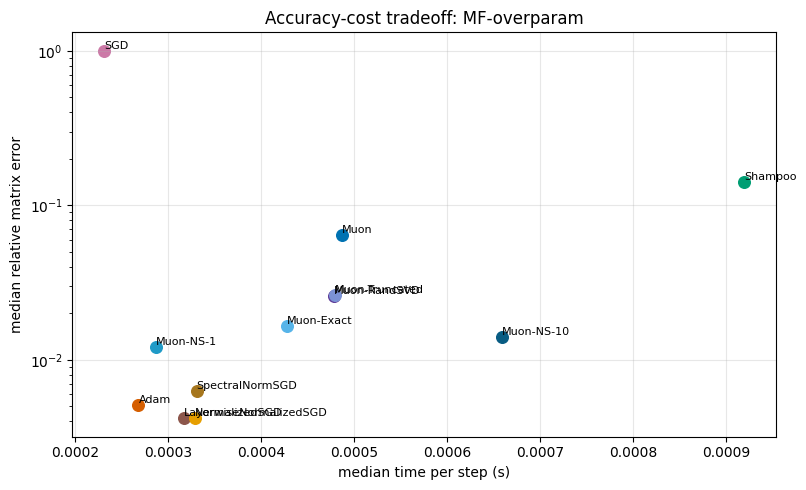

In [6]:
for setting in ["MS-hard", "MS-noisy", "MF-tiny", "MF-overparam"]:
    summary = run_summary[run_summary["setting"] == setting].groupby("algo", as_index=False, observed=True).agg(
        median_error=("relative_matrix_error", "median"),
        median_time_per_step=("time_per_step", "median"),
    )
    fig, ax = plt.subplots(figsize=(8.2, 5.0))
    for _, row in summary.iterrows():
        ax.scatter(row["median_time_per_step"], row["median_error"], color=plotting.algorithm_color(row["algo"]), s=70)
        ax.text(row["median_time_per_step"], row["median_error"], row["algo"], fontsize=8, ha="left", va="bottom")
    ax.set_title(f"Accuracy-cost tradeoff: {setting}")
    ax.set_xlabel("median time per step (s)")
    ax.set_ylabel("median relative matrix error")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    show_figure(fig)


### Muon Approximation Quality

This plot focuses on the approximation-quality part of the Problem cell's question by comparing only Muon-family polar approximations.

Each bar plot fixes one setting and compares only Muon-family variants. The horizontal axis is the approximation variant, such as fewer Newton-Schulz steps, exact polar update, truncation, or randomized SVD. The vertical axis is seed-median recovery error on a log scale. This plot asks how much of Muon's behavior depends on accurately approximating its polar-style update geometry.

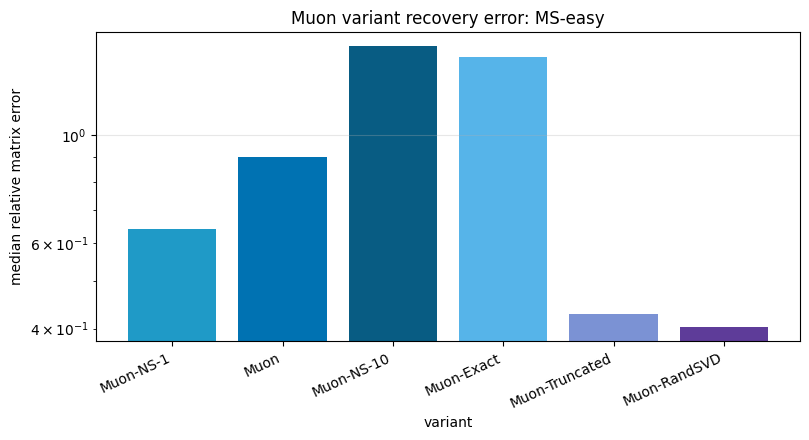

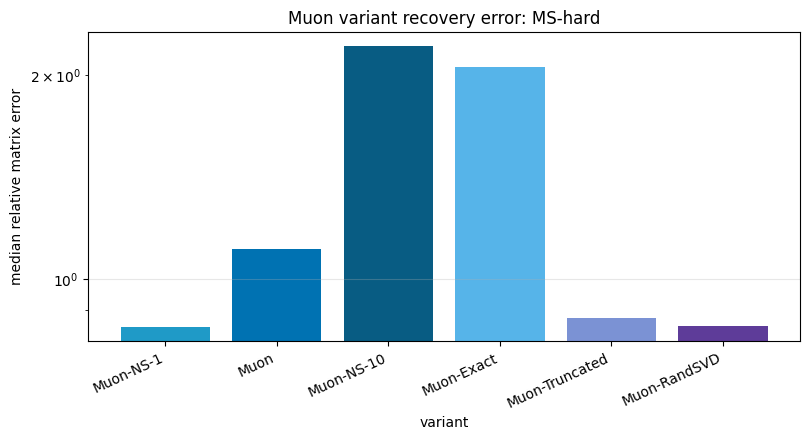

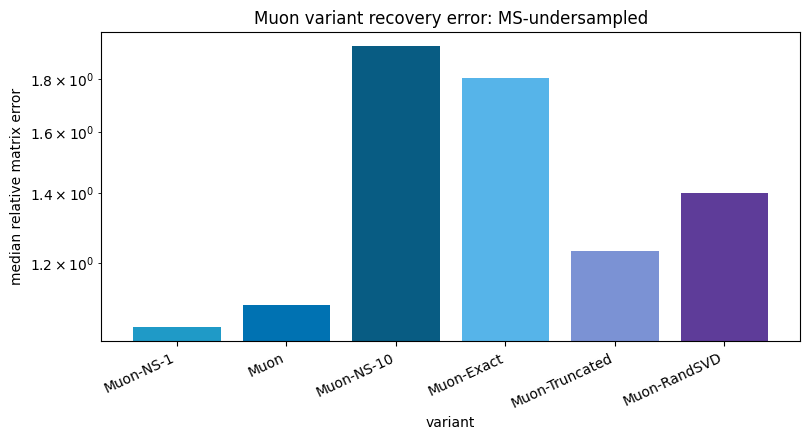

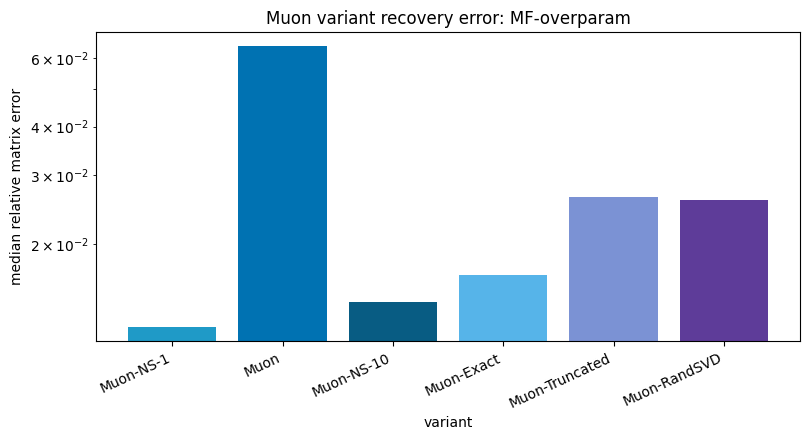

In [7]:
MUON_VARIANTS = ["Muon-NS-1", "Muon", "Muon-NS-10", "Muon-Exact", "Muon-Truncated", "Muon-RandSVD"]
for setting in ["MS-easy", "MS-hard", "MS-undersampled", "MF-overparam"]:
    sub = run_summary[(run_summary["setting"] == setting) & (run_summary["algo"].isin(MUON_VARIANTS))]
    summary = sub.groupby("algo", observed=True)["relative_matrix_error"].median().reindex(MUON_VARIANTS)
    fig, ax = plt.subplots(figsize=(8.2, 4.5))
    ax.bar(summary.index, summary.values, color=[plotting.algorithm_color(str(algo)) for algo in summary.index])
    ax.set_title(f"Muon variant recovery error: {setting}")
    ax.set_xlabel("variant")
    ax.set_ylabel("median relative matrix error")
    ax.set_yscale("log")
    ax.grid(axis="y", alpha=0.3)
    for tick in ax.get_xticklabels():
        tick.set_rotation(25)
        tick.set_ha("right")
    fig.tight_layout()
    show_figure(fig)


### Normalization Baseline Comparison

This plot focuses on the normalization part of the Problem cell's question by comparing Muon against gradient-normalization baselines.

Each bar plot fixes one setting and compares SGD, several normalized-SGD baselines, Muon, and Muon-Exact. The horizontal axis is method and the vertical axis is seed-median recovery error on a log scale. This is not a runtime plot; it asks whether simple gradient normalization can reproduce the accuracy of Muon-style matrix geometry.

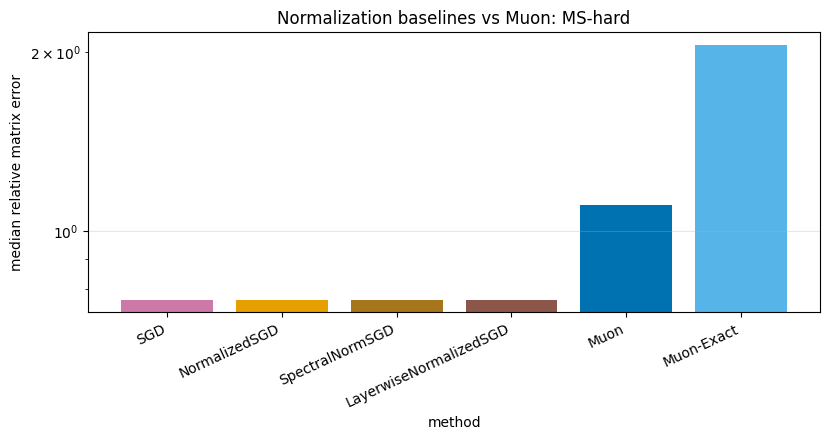

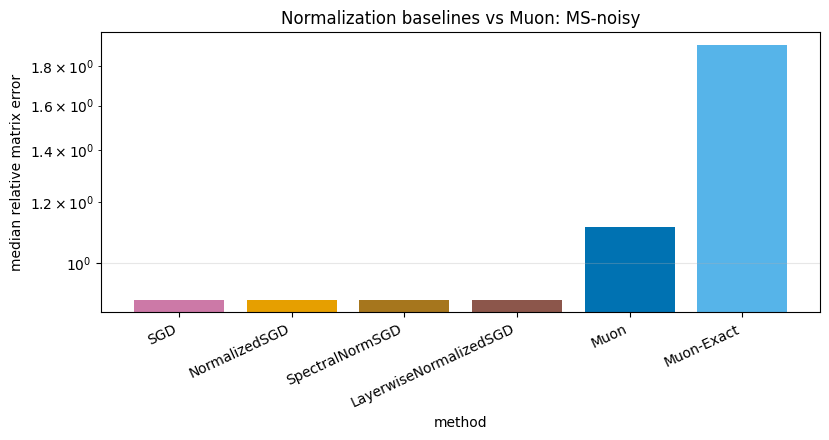

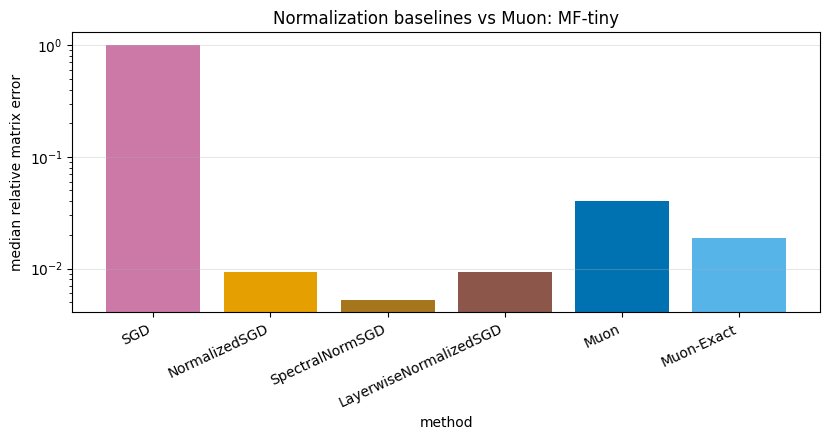

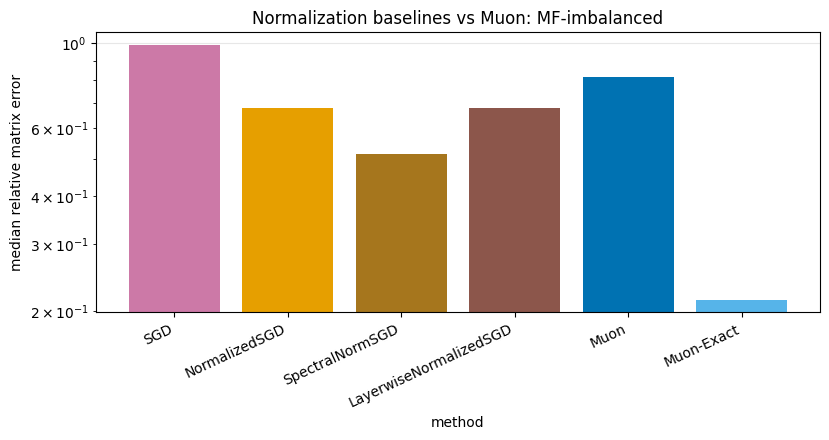

In [8]:
NORMALIZATION_SET = ["SGD", "NormalizedSGD", "SpectralNormSGD", "LayerwiseNormalizedSGD", "Muon", "Muon-Exact"]
for setting in ["MS-hard", "MS-noisy", "MF-tiny", "MF-imbalanced"]:
    sub = run_summary[(run_summary["setting"] == setting) & (run_summary["algo"].isin(NORMALIZATION_SET))]
    summary = sub.groupby("algo", observed=True)["relative_matrix_error"].median().reindex(NORMALIZATION_SET)
    fig, ax = plt.subplots(figsize=(8.4, 4.5))
    ax.bar(summary.index, summary.values, color=[plotting.algorithm_color(str(algo)) for algo in summary.index])
    ax.set_title(f"Normalization baselines vs Muon: {setting}")
    ax.set_xlabel("method")
    ax.set_ylabel("median relative matrix error")
    ax.set_yscale("log")
    ax.grid(axis="y", alpha=0.3)
    for tick in ax.get_xticklabels():
        tick.set_rotation(25)
        tick.set_ha("right")
    fig.tight_layout()
    show_figure(fig)


### Gradient-Update Cosine

The Problem cell contrasts update geometries; this plot shows how closely each variant aligns with steepest descent.

Each generated figure fixes one setting and compares update directions over time. The horizontal axis is diagnostic step $t$, color is optimizer variant, and the vertical value is seed-median $c_t=\langle -G_t,U_t\rangle/(\lVert G_t\rVert_F\lVert U_t\rVert_F)$. The zero line marks orthogonality to steepest descent. This plot helps distinguish variants that are accurate because they behave like descent from variants that take more geometrically transformed directions.

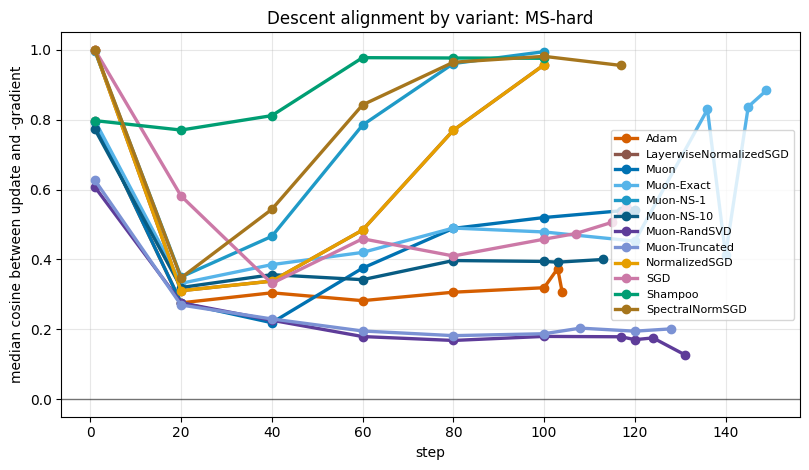

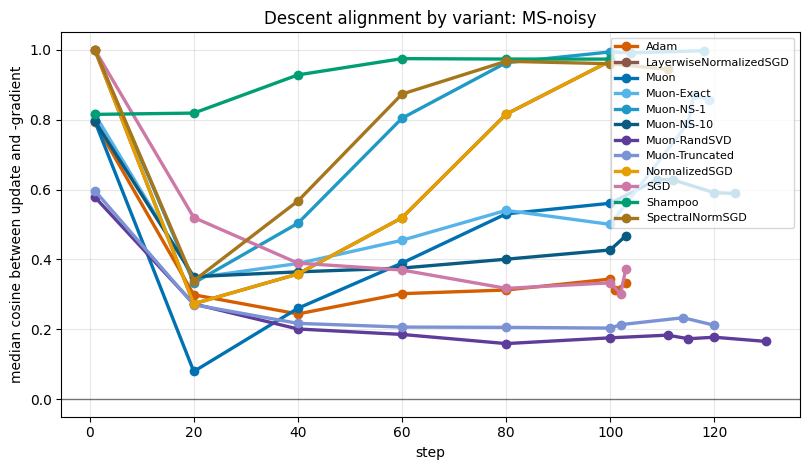

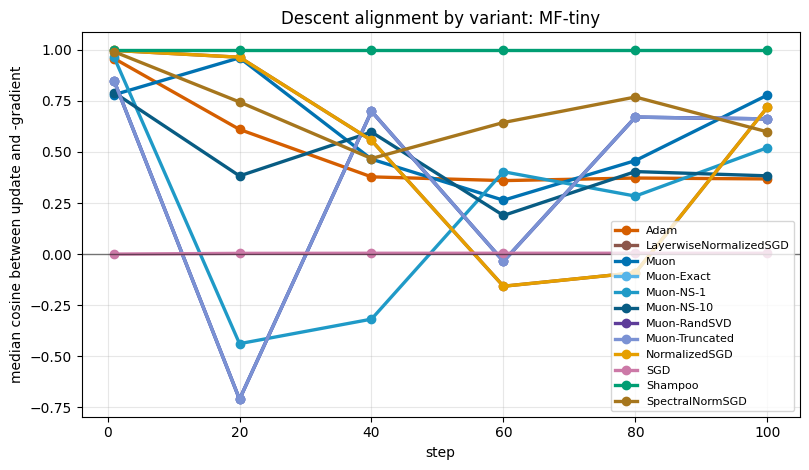

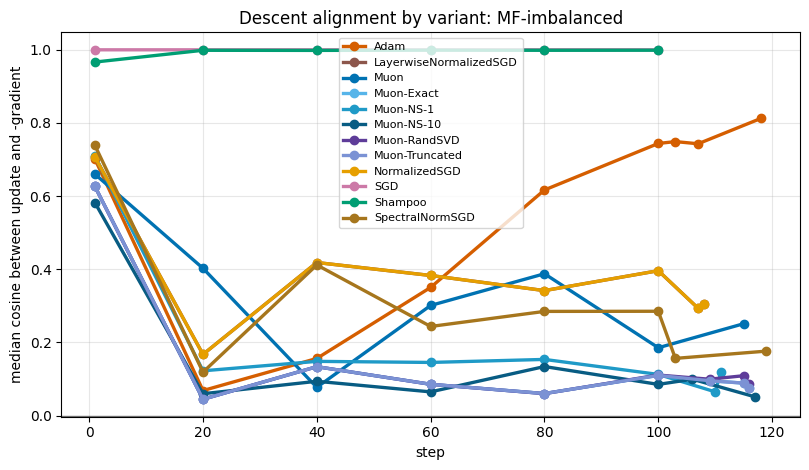

In [9]:
for setting in ["MS-hard", "MS-noisy", "MF-tiny", "MF-imbalanced"]:
    fig, ax = plotting.plot_metric_lines(
        runs[runs["setting"] == setting],
        x="step",
        metric="grad_update_cosine",
        title=f"Descent alignment by variant: {setting}",
        ylabel="median cosine between update and -gradient",
    )
    ax.axhline(0, color="black", linewidth=1, alpha=0.5)
    show_figure(fig)


### Update Effective Rank

The Problem cell emphasizes matrix update geometry; this plot checks whether variants produce different spectral ranks in $U_t$.

Each generated figure fixes one setting. The horizontal axis is step $t$, color is optimizer variant, and the vertical value is seed-median effective rank of the update $U_t$. Since Muon variants differ mainly in how they approximate or alter the matrix update, this plot shows whether those variants produce low-rank, high-rank, or spectrally flattened updates.

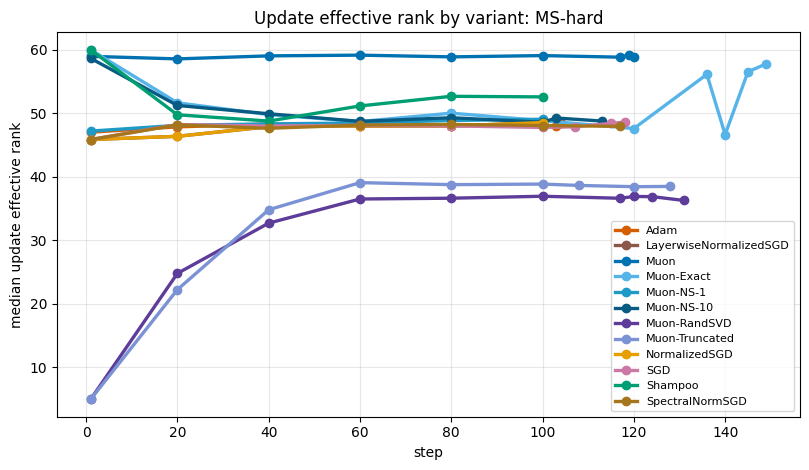

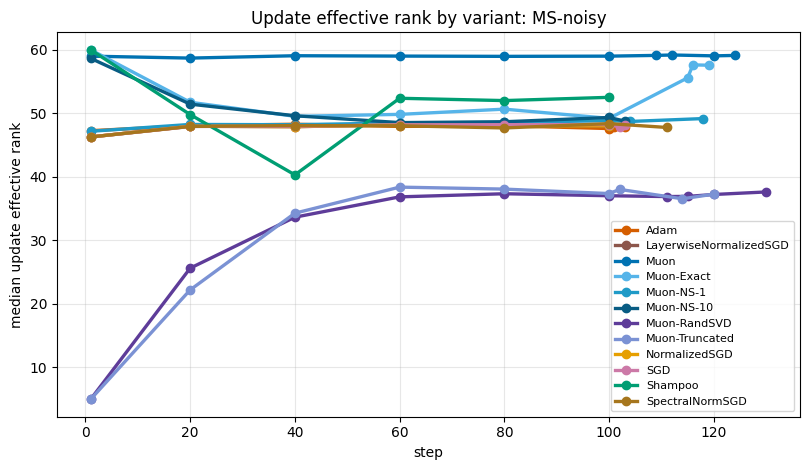

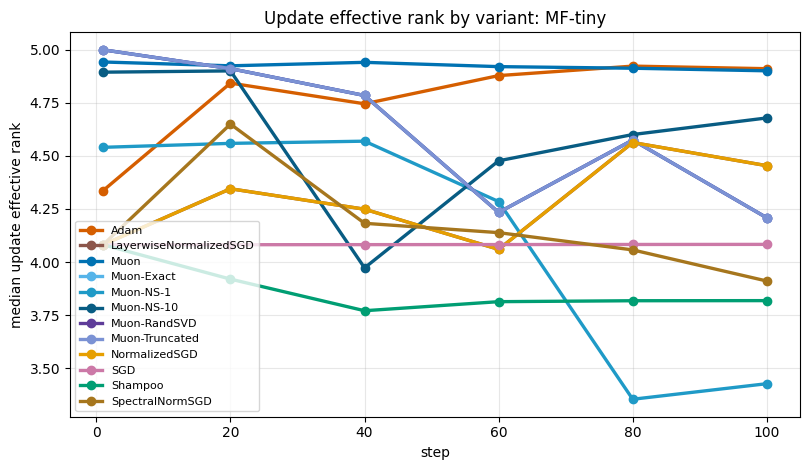

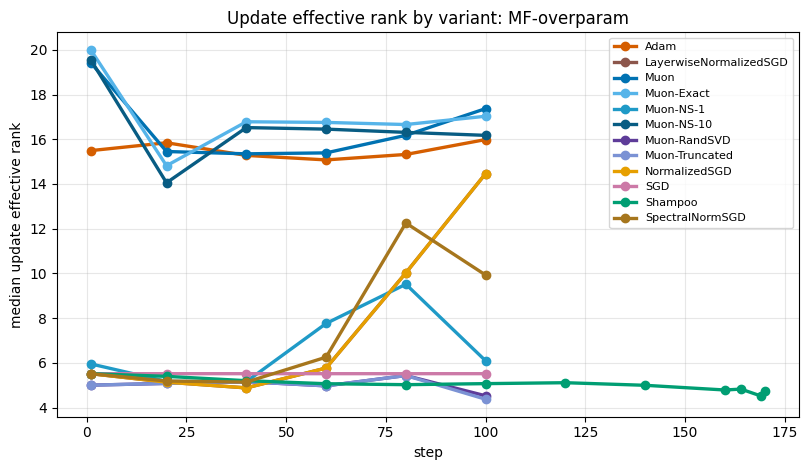

In [10]:
for setting in ["MS-hard", "MS-noisy", "MF-tiny", "MF-overparam"]:
    fig, ax = plotting.plot_metric_lines(
        runs[runs["setting"] == setting],
        x="step",
        metric="update_effective_rank",
        title=f"Update effective rank by variant: {setting}",
        ylabel="median update effective rank",
    )
    show_figure(fig)


### Representative Loss Curves

These curves show the optimization dynamics behind the endpoint accuracy comparisons in the Problem-cell variant study.

These figures show two representative settings with all methods overlaid. The horizontal axis is step $t$, the vertical axis is seed-median training loss, and color is optimizer or variant. Because this plot is intentionally crowded, use it for qualitative dynamics and then rely on the accuracy-cost and bar plots above for cleaner endpoint comparisons.

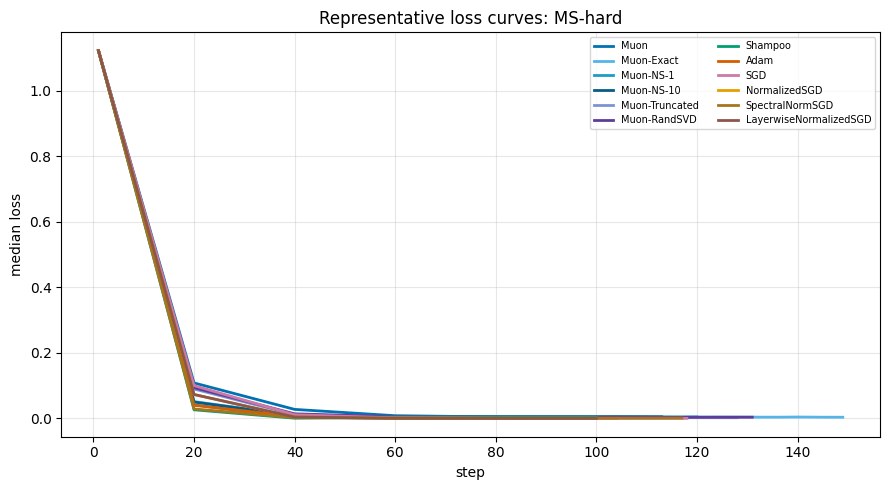

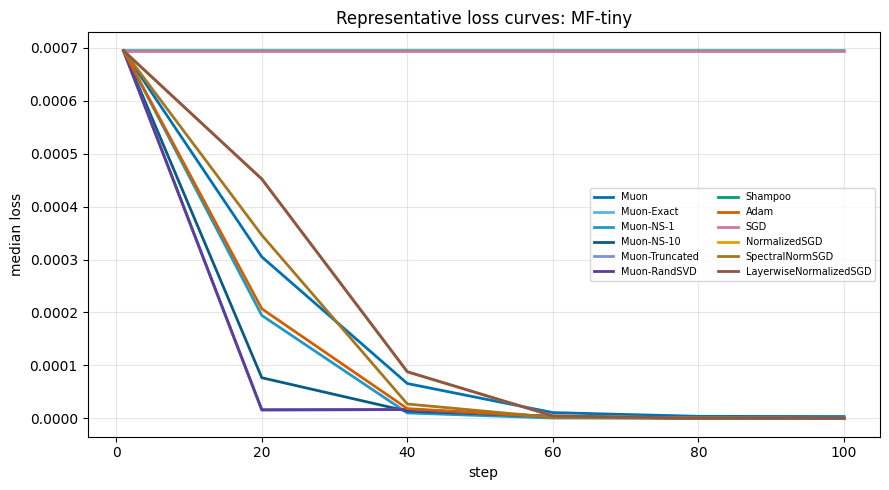

In [11]:
for setting in ["MS-hard", "MF-tiny"]:
    sub = runs[runs["setting"] == setting]
    fig, ax = plt.subplots(figsize=(9.0, 5.0))
    for algo in ALGOS:
        curve = sub[sub["algo"] == algo].groupby("step", as_index=False)["loss"].median()
        ax.plot(curve["step"], curve["loss"], color=plotting.algorithm_color(algo), linewidth=2.0, label=algo)
    ax.set_title(f"Representative loss curves: {setting}")
    ax.set_xlabel("step")
    ax.set_ylabel("median loss")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    show_figure(fig)


### Representative Log-Loss Curves

This is the same Problem-cell variant-dynamics view on a log axis, which is more useful when methods differ by multiplicative loss factors.

This repeats the representative loss curves with a logarithmic loss axis. The visual dimensions are setting, step, method color, and median loss. This is the better version for comparing late-time convergence and small endpoint differences across many variants.

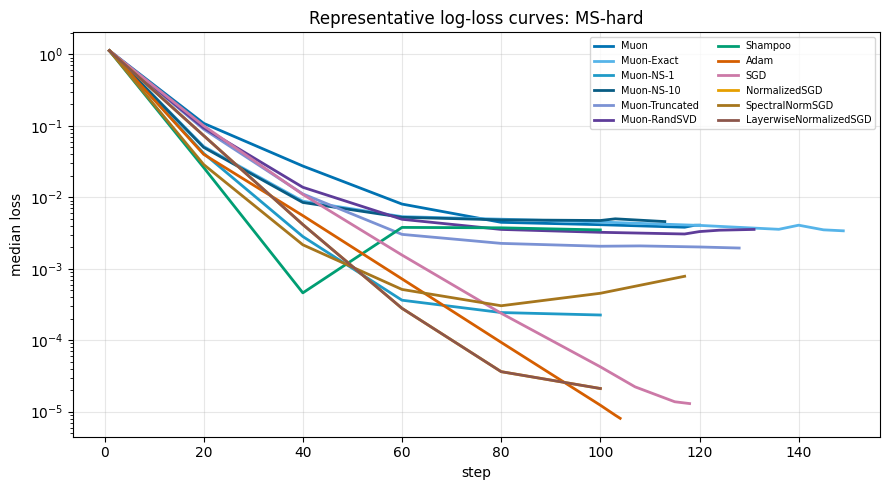

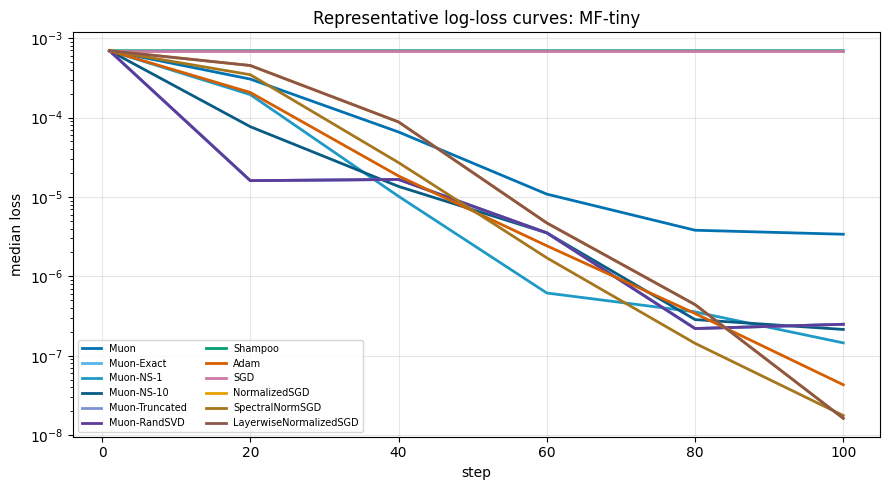

In [12]:
for setting in ["MS-hard", "MF-tiny"]:
    sub = runs[runs["setting"] == setting]
    fig, ax = plt.subplots(figsize=(9.0, 5.0))
    for algo in ALGOS:
        curve = sub[sub["algo"] == algo].groupby("step", as_index=False)["loss"].median()
        ax.plot(curve["step"], curve["loss"], color=plotting.algorithm_color(algo), linewidth=2.0, label=algo)
    ax.set_title(f"Representative log-loss curves: {setting}")
    ax.set_xlabel("step")
    ax.set_ylabel("median loss")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    show_figure(fig)


### Main Table


In [13]:
variant_table = run_summary.groupby(["setting", "algo"], as_index=False, observed=True).agg(
    median_recovery=("relative_matrix_error", "median"),
    median_loss=("final_loss", "median"),
    median_time_per_step=("time_per_step", "median"),
    median_cosine=("grad_update_cosine", "median"),
    median_update_rank=("update_effective_rank", "median"),
    divergence_rate=("diverged", "mean"),
)
IPython.display.display(variant_table)


,setting,algo,median_recovery,median_loss,median_time_per_step,median_cosine,median_update_rank,divergence_rate
0,MF-imbalanced,Adam,0.547629,0.000212,0.000328,0.749015,4.471275,0.0
1,MF-imbalanced,LayerwiseNormalizedSGD,0.677396,0.000322,0.000240,0.305620,4.038667,0.0
2,MF-imbalanced,Muon,0.814567,0.000452,0.000410,0.250955,4.918192,0.0
3,MF-imbalanced,Muon-Exact,0.214542,0.000036,0.000265,0.088524,4.259706,0.0
4,MF-imbalanced,Muon-NS-1,0.205410,0.000030,0.000300,0.108156,3.139735,0.0
...,...,...,...,...,...,...,...,...
91,MS-undersampled,Muon-Truncated,1.232041,0.000527,0.001916,0.354492,26.878172,0.0
92,MS-undersampled,NormalizedSGD,1.039222,0.000086,0.001297,0.959934,47.764069,0.0
93,MS-undersampled,SGD,1.039213,0.000008,0.001482,0.341693,47.888228,0.0
94,MS-undersampled,Shampoo,1.070532,0.012469,0.002112,0.970611,51.412347,0.0


### Reading The Result

If `NormalizedSGD` or `SpectralNormSGD` matches Muon across the hard settings, the main story is update-scale control. If Muon and Muon-Exact beat those baselines while also showing different update effective rank, the polar matrix geometry is contributing beyond scalar normalization.
